In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
all_features = pd.read_parquet("../all_features.parquet")
all_features.head()

,customer_id,customer_type,label,cash_value_ratio,emt_velocity_monthly_mean,income_transaction_gap_score,is_retired,is_unemployed,occupation_sector_id,spending_income_ratio,...,msb_net_retention_ratio,struct_total_near_n,struct_days_with_near,struct_max_near_in_day,struct_total_near_sum,tx_country_n,tx_province_n,tx_city_n,pct_tx_province_mismatch,pct_tx_city_mismatch
0,SYNID0100000167,IND,NaN,0.000000,0.000000,0.807090,0.0,0.0,2.0,0.000000,...,0.706175,0,0,0,0.0,0,0,0,1.000000,1.000000
1,SYNID0100000431,IND,NaN,0.183417,9.333333,NaN,0.0,0.0,18.0,NaN,...,-0.291106,0,0,0,0.0,1,7,21,1.000000,0.750000
2,SYNID0100000485,IND,0.0,0.037841,0.000000,1.460746,1.0,0.0,18.0,0.234281,...,0.328867,0,0,0,0.0,1,6,13,0.750000,0.975000
3,SYNID0100000539,IND,NaN,0.000000,3.500000,0.016742,1.0,0.0,18.0,0.863900,...,-0.968301,0,0,0,0.0,5,10,40,1.000000,0.673333
4,SYNID0100000932,IND,NaN,0.012255,1.000000,17.062930,1.0,0.0,18.0,1.579105,...,0.661526,0,0,0,0.0,2,12,40,0.598174,0.926941


In [3]:
all_features["customer_type_ind"] = np.where(all_features["customer_type"] == "IND", 0, 1)

# kurt_debit, kurt_credit all NA
all_features.drop(["customer_type", "kurt_debit", "kurt_credit"], axis=1, inplace=True)

In [4]:
labelled = all_features[all_features["label"].notnull()]
unlabelled = all_features[all_features["label"].isna()]

In [5]:
labelled.shape

(1000, 51)

In [6]:
unlabelled.shape

(60410, 51)

In [7]:
all_features.columns

Index(['customer_id', 'label', 'cash_value_ratio', 'emt_velocity_monthly_mean',
       'income_transaction_gap_score', 'is_retired', 'is_unemployed',
       'occupation_sector_id', 'spending_income_ratio',
       'rapid_outflow_ratio_24h', 'mean_debit', 'median_debit', 'std_debit',
       'iqr_debit', 'mad_debit', 'skew_debit', 'mean_credit', 'median_credit',
       'std_credit', 'iqr_credit', 'mad_credit', 'skew_credit',
       'mean_velocity', 'median_velocity', 'std_velocity', 'iqr_velocity',
       'mad_velocity', 'skew_velocity', 'late_night_txn_count',
       'late_night_ratio', 'weekend_txn_count', 'activity_span_days',
       'unique_merchant_categories', 'msb_tx_n', 'msb_active_days',
       'msb_channels_n', 'id_msb_in_total', 'id_msb_out_total',
       'msb_tx_per_day', 'msb_pass_through_ratio', 'msb_net_retention_ratio',
       'struct_total_near_n', 'struct_days_with_near',
       'struct_max_near_in_day', 'struct_total_near_sum', 'tx_country_n',
       'tx_province_n', 't

Clustering Labelled Data

-- using mice to impute missing data, cannot use pmm like in R so not great method

In [8]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

labelled = all_features[all_features["label"].notnull()]
labelled.drop(["customer_id"], axis=1, inplace=True)

unlabelled = all_features[all_features["label"].isnull()]
unlabelled.drop(["customer_id"], axis=1, inplace=True)

imp = IterativeImputer(max_iter=20, random_state=42)

labelled_imp = imp.fit_transform(labelled)
unlabelled_imp = imp.transform(unlabelled)

labelled_imp = pd.DataFrame(labelled_imp, columns=labelled.columns, index=labelled.index)
unlabelled_imp = pd.DataFrame(unlabelled_imp, columns=unlabelled.columns, index=unlabelled.index)
columns = unlabelled_imp.columns

labelled_imp.head()

/var/folders/h2/wp9729hs033gv8ywbz5q4b_h0000gn/T/ipykernel_6782/1210709540.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labelled.drop(["customer_id"], axis=1, inplace=True)
/var/folders/h2/wp9729hs033gv8ywbz5q4b_h0000gn/T/ipykernel_6782/1210709540.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unlabelled.drop(["customer_id"], axis=1, inplace=True)


,label,cash_value_ratio,emt_velocity_monthly_mean,income_transaction_gap_score,is_retired,is_unemployed,occupation_sector_id,spending_income_ratio,rapid_outflow_ratio_24h,mean_debit,...,struct_total_near_n,struct_days_with_near,struct_max_near_in_day,struct_total_near_sum,tx_country_n,tx_province_n,tx_city_n,pct_tx_province_mismatch,pct_tx_city_mismatch,customer_type_ind
2,0.0,0.037841,0.0,1.460746,1.0,0.0,18.0,0.234281,0.0,1229.440000,...,0.0,0.0,0.0,0.0,1.0,6.0,13.0,0.75,0.975,0.0
103,0.0,0.000000,0.0,0.565197,0.0,0.0,18.0,0.000000,0.0,1192.126667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00,1.000,0.0
164,0.0,0.000000,0.0,0.036114,1.0,0.0,18.0,0.000000,0.0,619.537618,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00,1.000,0.0
274,0.0,0.000000,1.0,1.215037,0.0,1.0,17.0,0.000000,0.0,655.498168,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00,1.000,0.0
280,0.0,0.000000,2.0,0.273064,1.0,0.0,18.0,0.000000,0.0,949.250000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00,1.000,0.0


In [9]:
X_train = labelled_imp.drop(["label"], axis=1)
cols = X_train.columns
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
y_train = labelled_imp["label"]

results = []
silhouette_scores = []

for k in range(2, 20):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    clusters = kmeans.fit_predict(X_train)

    tmp = pd.DataFrame({"label": y_train, "cluster": clusters})

    labelled_tmp = tmp[tmp["label"].notna()]
    summary = (labelled_tmp.groupby("cluster")["label"]
               .agg(labeled_count="count", positives="sum", positive_rate="mean")
               .reset_index()
               .sort_values("positive_rate", ascending=False))

    sil = silhouette_score(X_train, clusters)

    results.append({"k": k, "silhouette": sil, "summary": summary})
    silhouette_scores.append({"k": k, "silhouette": sil})

    print(f"\n=== k={k} | silhouette={sil:.3f} ===")
    print(summary.to_string(index=False))


=== k=2 | silhouette=0.732 ===
 cluster  labeled_count  positives  positive_rate
       1             15        2.0       0.133333
       0            985        8.0       0.008122

=== k=3 | silhouette=0.295 ===
 cluster  labeled_count  positives  positive_rate
       1             15        2.0       0.133333
       2            230        4.0       0.017391
       0            755        4.0       0.005298

=== k=4 | silhouette=0.124 ===
 cluster  labeled_count  positives  positive_rate
       1             15        2.0       0.133333
       2            151        2.0       0.013245
       3            394        3.0       0.007614
       0            440        3.0       0.006818

=== k=5 | silhouette=0.133 ===
 cluster  labeled_count  positives  positive_rate
       4             23        3.0       0.130435
       2            163        2.0       0.012270
       0            456        3.0       0.006579
       3            352        2.0       0.005682
       1              

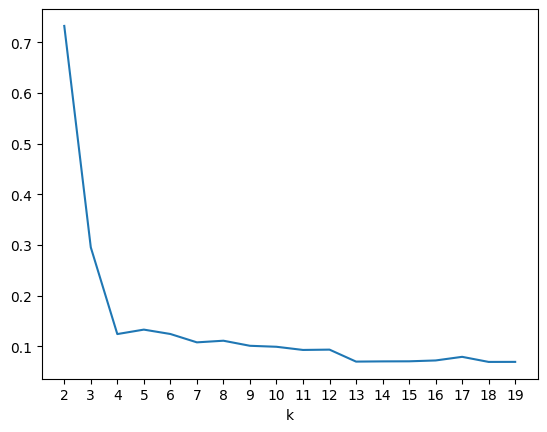

In [10]:
# scores = [i["silhouette"] for i in silhouette_scores]
# k = [i["k"] for i in silhouette_scores]
#
# plt.plot(k, scores)
# plt.xticks(range(min(k), max(k)+1))
# plt.xlabel("k")
# plt.show()

optimal clusters on labelled data

In [11]:
k_opt = max(silhouette_scores, key=lambda x: x[1])[0]

kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init="auto")
train_clusters = kmeans.fit_predict(X_train)

tmp = pd.DataFrame({"label": y_train, "cluster": train_clusters}, index=labelled_imp.index)
labelled_tmp = tmp[tmp["label"].notna()]

cluster_profile = (labelled_tmp.groupby("cluster")["label"]
                   .agg(labeled_count="count", positives="sum", positive_rate="mean")
                   .reset_index()
                   .sort_values("positive_rate", ascending=False))
cluster_profile

,cluster,labeled_count,positives,positive_rate
1,1,15,2.0,0.133333
2,2,151,2.0,0.013245
3,3,394,3.0,0.007614
0,0,440,3.0,0.006818


the labelled classes aren't segmented very well so cluster predictions for unlabelled data won't make sense

# new strat: fit model then cluster based on predictions

In [12]:
# fit xgboost
X_train = labelled_imp.drop(columns=["label"])
y_train = labelled_imp["label"]

X_test = unlabelled_imp

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train_scaled, y_train)

train_prob = xgb.predict_proba(X_train_scaled)[:,1]

logit = np.log(train_prob / (1 - train_prob))

cluster_features = np.column_stack([train_prob, logit])

k=2, silhouette=0.5760
k=3, silhouette=0.5510
k=4, silhouette=0.5351
k=5, silhouette=0.5391
k=6, silhouette=0.5418
k=7, silhouette=0.5307
k=8, silhouette=0.5348
k=9, silhouette=0.5430
k=10, silhouette=0.5403
k=11, silhouette=0.5438
k=12, silhouette=0.5444
k=13, silhouette=0.5371
k=14, silhouette=0.5341
k=15, silhouette=0.5363
k=16, silhouette=0.5395
k=17, silhouette=0.5527
k=18, silhouette=0.5376
k=19, silhouette=0.5329


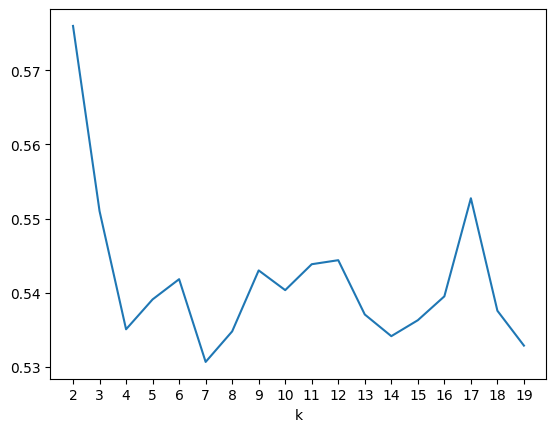

In [13]:
silhouette_scores = []

for k in range(2, 20):

    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")

    clusters = kmeans.fit_predict(cluster_features)

    sil = silhouette_score(cluster_features, clusters)

    silhouette_scores.append((k, sil))

    print(f"k={k}, silhouette={sil:.4f}")

# scores = [i[1] for i in silhouette_scores]
# k = [i[0] for i in silhouette_scores]
#
# plt.plot(k, scores)
# plt.xticks(range(min(k), max(k)+1))
# plt.xlabel("k")
# plt.show()

In [14]:
# re-fit with optimal k
k_opt = 7

kmeans_final = KMeans(
    n_clusters=k_opt,
    random_state=42,
    n_init="auto")

final_clusters = kmeans_final.fit_predict(cluster_features)

labelled_imp["risk_cluster"] = final_clusters
labelled_imp["risk_prob"] = train_prob

In [15]:
# risk prob summary for each cluster
cluster_summary = (
    labelled_imp
    .groupby("risk_cluster")
    .agg(
        count=("label", "count"),
        positives=("label", "sum"),
        positive_rate=("label", "mean"),
        avg_prob=("risk_prob", "mean"))
    .sort_values("positive_rate"))

cluster_summary

,count,positives,positive_rate,avg_prob
risk_cluster,,,,
0,199,0.0,0.0,0.000025
1,148,0.0,0.0,0.001173
2,91,0.0,0.0,0.004604
3,235,0.0,0.0,0.000338
5,260,0.0,0.0,0.000096
6,57,0.0,0.0,0.021979
4,10,10.0,1.0,0.795359


In [16]:
# apply to unlabelled data

# predict prbabilities
X_new_scaled = scaler.transform(unlabelled_imp[X_train.columns])

new_prob = xgb.predict_proba(X_new_scaled)[:,1]

new_logit = np.log(new_prob / (1 - new_prob))

new_features = np.column_stack([new_prob, new_logit])

# predict clusters
new_clusters = kmeans_final.predict(new_features)

# assign risk probabilities to cluster
unlabelled_imp["risk_prob"] = new_prob
unlabelled_imp["risk_cluster"] = new_clusters

cluster_risk_map = cluster_summary["positive_rate"]

unlabelled_imp["cluster_risk"] = (unlabelled_imp["risk_cluster"].map(cluster_risk_map))

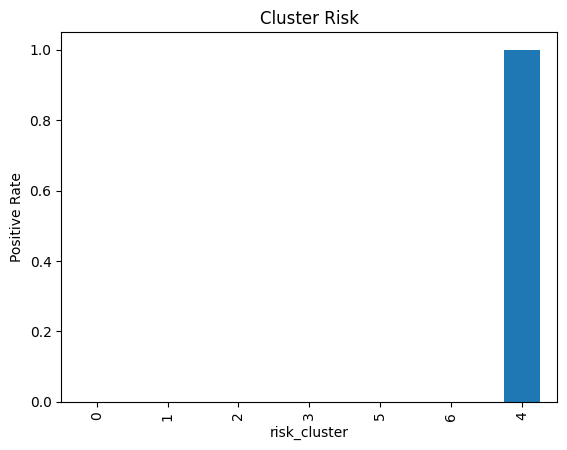

In [17]:
cluster_summary["positive_rate"].plot(kind="bar")

plt.ylabel("Positive Rate")
plt.title("Cluster Risk")

plt.show()

# now: fitting RF, XGBoost with hyperparameter tuning to see if it makes a difference

In [18]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings(
    "ignore",
    category=ConvergenceWarning,
    module="sklearn.impute")

In [19]:
X = labelled.drop(columns=["label"])
y = labelled["label"].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# RANDOM FOREST
rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced")

rf_pipe = Pipeline(steps=[
    ("imputer", IterativeImputer(max_iter=20, random_state=42)),
    ("scaler", StandardScaler()),
    ("model", rf)])

rf_param_dist = {
    "model__n_estimators": [300, 500, 800, 1200],
    "model__max_depth": [None, 5, 10, 20, 40],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8, 16],
    "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.8],
    "model__bootstrap": [True, False],
}

rf_search = RandomizedSearchCV(
    rf_pipe,
    rf_param_dist,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1)

rf_search.fit(X_train, y_train)

print("\n=== Random Forest ===")
print("Best CV ROC-AUC:", rf_search.best_score_)
print("Best params:", rf_search.best_params_)

rf_best = rf_search.best_estimator_
rf_valid_prob = rf_best.predict_proba(X_valid)[:, 1]
print("Validation ROC-AUC:", roc_auc_score(y_valid, rf_valid_prob))

# XGBOOST
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist")

xgb_pipe = Pipeline(steps=[
    ("imputer", IterativeImputer(max_iter=20, random_state=42)),
    ("scaler", StandardScaler()),
    ("model", xgb)
])

xgb_param_dist = {
    "model__n_estimators": [300, 500, 800, 1200],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__min_child_weight": [1, 2, 5, 10],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__gamma": [0, 0.5, 1, 2],
    "model__reg_alpha": [0, 1e-3, 1e-2, 1e-1, 1],
    "model__reg_lambda": [0.5, 1, 2, 5],
    "model__scale_pos_weight": [1.0, scale_pos_weight],
}

xgb_search = RandomizedSearchCV(
    xgb_pipe,
    xgb_param_dist,
    n_iter=50,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("\n=== XGBoost ===")
print("Best CV ROC-AUC:", xgb_search.best_score_)
print("Best params:", xgb_search.best_params_)

xgb_best = xgb_search.best_estimator_
xgb_valid_prob = xgb_best.predict_proba(X_valid)[:, 1]
print("Validation ROC-AUC:", roc_auc_score(y_valid, xgb_valid_prob))

Fitting 5 folds for each of 40 candidates, totalling 200 fits

=== Random Forest ===
Best CV ROC-AUC: 0.7626781307220764
Best params: {'model__n_estimators': 1200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 16, 'model__max_features': 0.5, 'model__max_depth': 20, 'model__bootstrap': True}
Holdout ROC-AUC: 0.8914141414141414
Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== XGBoost ===
Best CV ROC-AUC: 0.7981808773186848
Best params: {'model__subsample': 1.0, 'model__scale_pos_weight': 1.0, 'model__reg_lambda': 0.5, 'model__reg_alpha': 0.01, 'model__n_estimators': 800, 'model__min_child_weight': 2, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__gamma': 0.5, 'model__colsample_bytree': 0.6}
Holdout ROC-AUC: 0.8863636363636364


# re-fitting and re-clustering on best-fitting XGBoost

In [37]:
# fit xgboost
X_train = labelled_imp[columns]
y_train = labelled_imp["label"]

X_test = unlabelled_imp

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

xgb = xgb_search.best_estimator_

xgb.fit(X_train_scaled, y_train)

train_prob = xgb.predict_proba(X_train_scaled)[:,1]

logit = np.log(train_prob / (1 - train_prob))

cluster_features = np.column_stack([train_prob, logit])

k=2, silhouette=0.6046
k=3, silhouette=0.5698
k=4, silhouette=0.5719
k=5, silhouette=0.5364
k=6, silhouette=0.5351
k=7, silhouette=0.5375
k=8, silhouette=0.5515
k=9, silhouette=0.5282
k=10, silhouette=0.5183
k=11, silhouette=0.5398
k=12, silhouette=0.5440
k=13, silhouette=0.5458
k=14, silhouette=0.5444
k=15, silhouette=0.5356
k=16, silhouette=0.5311
k=17, silhouette=0.5282
k=18, silhouette=0.5342
k=19, silhouette=0.5319


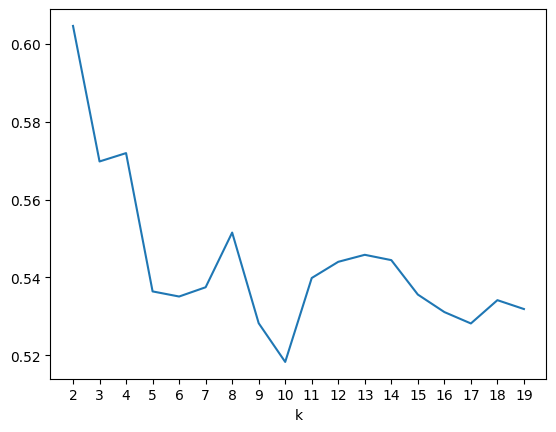

In [38]:
silhouette_scores = []

for k in range(2, 20):

    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")

    clusters = kmeans.fit_predict(cluster_features)

    sil = silhouette_score(cluster_features, clusters)

    silhouette_scores.append((k, sil))

    print(f"k={k}, silhouette={sil:.4f}")

scores = [i[1] for i in silhouette_scores]
k = [i[0] for i in silhouette_scores]

plt.plot(k, scores)
plt.xticks(range(min(k), max(k)+1))
plt.xlabel("k")
plt.show()

In [39]:
# re-fit with optimal k
# k_opt = max(silhouette_scores, key=lambda x: x[1])[0]
k_opt = 5

kmeans_final = KMeans(
    n_clusters=k_opt,
    random_state=42,
    n_init="auto")

final_clusters = kmeans_final.fit_predict(cluster_features)

labelled_imp["xgb_risk_cluster"] = final_clusters
labelled_imp["xgb_risk_prob"] = train_prob

# risk prob summary for each cluster
xgb_cluster_summary = (
    labelled_imp
    .groupby("xgb_risk_cluster")
    .agg(
        count=("label", "count"),
        positives=("label", "sum"),
        xgb_positive_rate=("label", "mean"),
        avg_prob=("xgb_risk_prob", "mean"))
    .sort_values("xgb_positive_rate"))

xgb_cluster_summary

,count,positives,xgb_positive_rate,avg_prob
xgb_risk_cluster,,,,
0,328,0.0,0.000000,0.000317
1,244,0.0,0.000000,0.003382
4,315,0.0,0.000000,0.000942
3,103,1.0,0.009709,0.023239
2,10,9.0,0.900000,0.631220


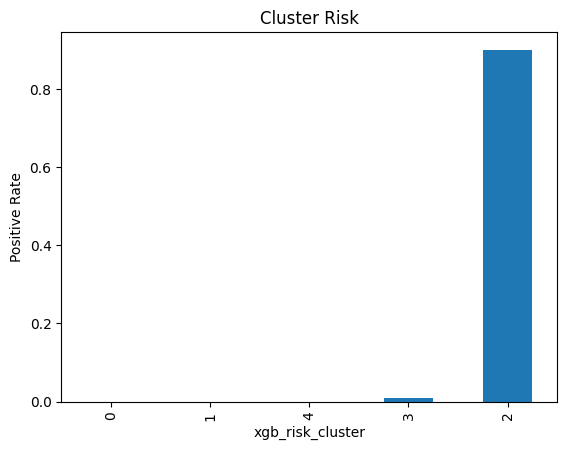

In [40]:
# apply to unlabelled data

# predict prbabilities
X_new_scaled = scaler.transform(unlabelled_imp[columns])

xgb_new_prob = xgb.predict_proba(X_new_scaled)[:,1]

xgb_new_logit = np.log(xgb_new_prob / (1 - xgb_new_prob))

xgb_new_features = np.column_stack([xgb_new_prob, xgb_new_logit])

# predict clusters
xgb_new_clusters = kmeans_final.predict(xgb_new_features)

# assign risk probabilities to cluster
unlabelled_imp["xgb_risk_prob"] = xgb_new_prob
unlabelled_imp["xgb_risk_cluster"] = xgb_new_clusters

xgb_cluster_risk_map = xgb_cluster_summary["xgb_positive_rate"]

unlabelled_imp["xgb_cluster_risk"] = (unlabelled_imp["xgb_risk_cluster"].map(cluster_risk_map))

xgb_cluster_summary["xgb_positive_rate"].plot(kind="bar")
plt.ylabel("Positive Rate")
plt.title("Cluster Risk")
plt.show()

# re-fitting and re-clustering on best-fitting RF

In [41]:
X_train = labelled_imp[columns]
y_train = labelled_imp["label"].astype(int)

rf = rf_search.best_estimator_
rf.fit(X_train, y_train)

train_prob = rf.predict_proba(X_train)[:, 1]

eps = 1e-6
p = np.clip(train_prob, eps, 1 - eps)
logit = np.log(p / (1 - p))

cluster_features = np.column_stack([p, logit])

k=2, silhouette=0.7906
k=3, silhouette=0.6184
k=4, silhouette=0.5677
k=5, silhouette=0.5759
k=6, silhouette=0.5691
k=7, silhouette=0.5687
k=8, silhouette=0.5647
k=9, silhouette=0.5730
k=10, silhouette=0.5722
k=11, silhouette=0.6014
k=12, silhouette=0.5736
k=13, silhouette=0.5846
k=14, silhouette=0.5820
k=15, silhouette=0.5781
k=16, silhouette=0.6003
k=17, silhouette=0.6040
k=18, silhouette=0.5940
k=19, silhouette=0.6035


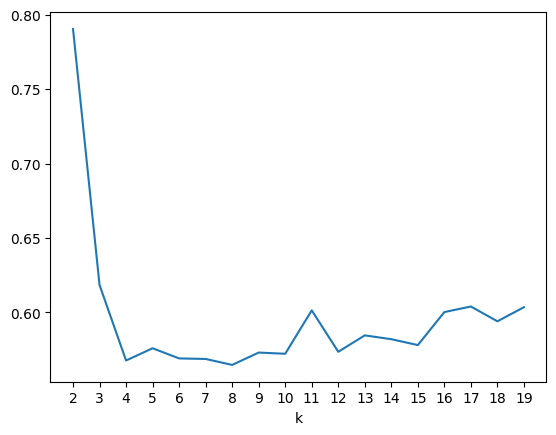

In [43]:
silhouette_scores = []

for k in range(2, 20):

    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")

    clusters = kmeans.fit_predict(cluster_features)

    sil = silhouette_score(cluster_features, clusters)

    silhouette_scores.append((k, sil))

    print(f"k={k}, silhouette={sil:.4f}")

scores = [i[1] for i in silhouette_scores]
k = [i[0] for i in silhouette_scores]

plt.plot(k, scores)
plt.xticks(range(min(k), max(k)+1))
plt.xlabel("k")
plt.show()

In [44]:
# re-fit with optimal k
#k_opt = max(silhouette_scores, key=lambda x: x[1])[0]
k_opt = 5

kmeans_final = KMeans(n_clusters=k_opt, random_state=42, n_init="auto")
final_clusters = kmeans_final.fit_predict(cluster_features)

labelled_imp["rf_risk_prob"] = train_prob
labelled_imp["rf_risk_cluster"] = final_clusters

rf_cluster_summary = (
    labelled_imp.groupby("rf_risk_cluster")
    .agg(count=("label", "count"),
         positives=("label", "sum"),
         rf_positive_rate=("label", "mean"),
         avg_prob=("rf_risk_prob", "mean"))
    .sort_values("rf_positive_rate")
)
rf_cluster_summary

,count,positives,rf_positive_rate,avg_prob
rf_risk_cluster,,,,
0,329,0.0,0.00000,0.015078
1,64,0.0,0.00000,0.000000
2,241,0.0,0.00000,0.089185
4,267,0.0,0.00000,0.002730
3,99,10.0,0.10101,0.393951


/Users/rebeccalee/Library/Python/3.11/lib/python/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but IterativeImputer was fitted with feature names
  warnings.warn(


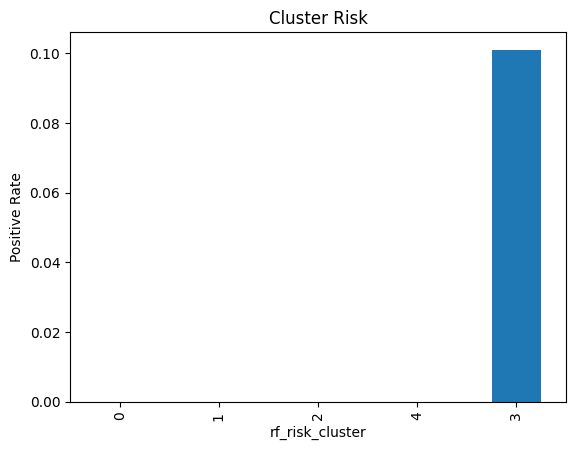

In [54]:
# apply to unlabelled data

# predict prbabilities
X_new_scaled = scaler.transform(unlabelled_imp[columns])

rf_new_prob = rf.predict_proba(X_new_scaled)[:,1]

rf_new_p = np.clip(rf_new_prob, 1e-6, 1 - 1e-6) # prevent 0 div
rf_new_logit = np.log(rf_new_p / (1 - rf_new_p))

rf_new_features = np.column_stack([rf_new_prob, rf_new_logit])

# predict clusters
rf_new_clusters = kmeans_final.predict(rf_new_features)

# assign risk probabilities to cluster
unlabelled_imp["rf_risk_prob"] = rf_new_prob
unlabelled_imp["rf_risk_cluster"] = rf_new_clusters

rf_cluster_risk_map = rf_cluster_summary["rf_positive_rate"]

unlabelled_imp["rf_cluster_risk"] = (unlabelled_imp["rf_risk_cluster"].map(rf_cluster_risk_map))

rf_cluster_summary["rf_positive_rate"].plot(kind="bar")
plt.ylabel("Positive Rate")
plt.title("Cluster Risk")

plt.show()

In [52]:
# correlation of risk probabilities
unlabelled_imp[["rf_risk_prob", "xgb_risk_prob"]].corr()

,rf_risk_prob,xgb_risk_prob
rf_risk_prob,1.000000,0.102904
xgb_risk_prob,0.102904,1.000000


In [55]:
# correlation of clusters
unlabelled_imp[["rf_cluster_risk", "xgb_cluster_risk"]].corr()

,rf_cluster_risk,xgb_cluster_risk
rf_cluster_risk,1.000000,-0.042698
xgb_cluster_risk,-0.042698,1.000000


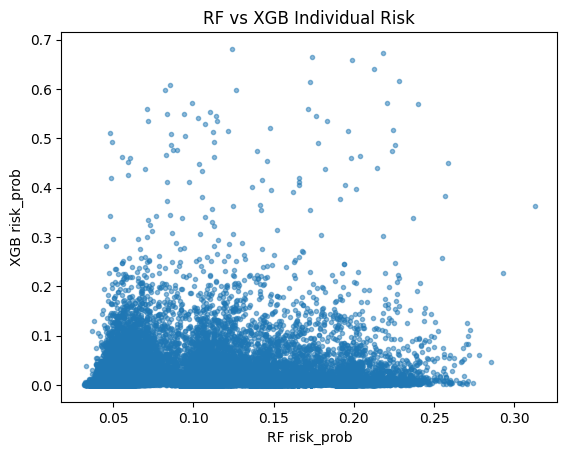

In [48]:
plt.scatter(unlabelled_imp["rf_risk_prob"], unlabelled_imp["xgb_risk_prob"], marker=".", alpha=0.5)
plt.xlabel("RF risk_prob")
plt.ylabel("XGB risk_prob")
plt.title("RF vs XGB Individual Risk")
plt.show()